# Brennan Kalinowski
# DSCC 383W Mini Project

## Part 1: Descriptive Analysis
### a) Create a table that contains information on minimum, average, median, and maximum for the following: tweet length (#characters and #words) (text column), hashtag length (#characters and #words) (hashtags column) (Add your table to the report.)
### Insert lemmatizer.py code with function tweet_cleaner

In [1]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet  # Import wordnet
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

##Tags the words in the tweets
def nltk_tag_to_wordnet_tag(nltk_tag):
    if nltk_tag.startswith('J'):
        return(wordnet.ADJ)
    elif nltk_tag.startswith('V'):
        return(wordnet.VERB)
    elif nltk_tag.startswith('N'):
        return(wordnet.NOUN)
    elif nltk_tag.startswith('R'):
        return(wordnet.ADV)
    else:          
        return(None)
    
# FUNCTION TWEET CLEANER
import re

def tweet_cleaner(tweet):
    """
    Cleans the input tweet by removing URLs, special characters,
    and extra spaces, and converting text to lowercase.

    Args:
        tweet (str): The raw tweet text.

    Returns:
        str: The cleaned tweet.
    """
    # Remove URLs
    tweet = re.sub(r"http\\S+|www\\.\\S+", "", tweet)
    # Remove special characters and numbers
    tweet = re.sub(r"[^a-zA-Z\\s]", "", tweet)
    # Convert to lowercase
    tweet = tweet.lower()
    # Remove extra spaces
    tweet = re.sub(r"\\s+", " ", tweet).strip()
    return tweet

##Lemmatizes the words in tweets and returns the cleaned and lemmatized tweet
def lemmatize_tweet(tweet):
    #tokenize the tweet and find the POS tag for each token
    tweet = tweet_cleaner(tweet) #tweet_cleaner() will be the function you will write
    nltk_tagged = nltk.pos_tag(nltk.word_tokenize(tweet))  
    #tuple of (token, wordnet_tag)
    wordnet_tagged = map(lambda x: (x[0], nltk_tag_to_wordnet_tag(x[1])), nltk_tagged)
    lemmatized_tweet = []
    for word, tag in wordnet_tagged:
        if tag is None:
            #if there is no available tag, append the token as is
            lemmatized_tweet.append(word)
        else:        
            #else use the tag to lemmatize the token
            lemmatized_tweet.append(lemmatizer.lemmatize(word, tag))
    return(" ".join(lemmatized_tweet))

### Load data and imports

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Load data
training_data = pd.read_csv("Desktop/DSCC383W/MiniP/training_data.csv")

training_data

,favorite_count,full_text,hashtags,retweet_count,year,dim1_nominate,dim2_nominate
0,8,b'WATCH my speech on the @SenateFloor to learn...,PatientFreedomAct,3,2017,0.243962,0.170366
1,2,b'Boehner delays leadership races. Only speake...,rossformajoritywhip,3,2015,0.561728,0.089540
2,5,"b""I'll be sharing #scarynumbers about #governm...",scarynumbers governmentspending,4,2014,0.513246,-0.224541
3,34,"b""#OTD in '64, LBJ took important step towards...",OTD,14,2017,-0.241932,0.097843
4,23,b'My bipartisan bill is a step toward protecti...,VA07,7,2020,-0.225722,0.329999
...,...,...,...,...,...,...,...
333982,97,"b""I am working to make Social Security stronge...",ExpandSocialSecurity,29,2018,-0.423522,0.005929
333983,11,b'Climate change -&gt; altered CA forest ecosy...,actonclimate,11,2016,-0.436272,-0.546745
333984,82,b'The @USChamber and other business lobbying g...,climate,34,2019,-0.309244,-0.070852
333985,1,b'I look forward to answering constituent\xe2\...,TeleTownHall,1,2016,-0.516671,0.205851


### Functions to compute tweet lengths and hashtag metrics

In [3]:
def tweet_char_length(tweet):
    return len(str(tweet))

def tweet_word_count(tweet):
    return len(lemmatize_tweet(tweet).split())

def hashtag_char_length(hashtags):
    return len(str(hashtags)) if pd.notna(hashtags) else 0

def hashtag_word_count(hashtags):
    if pd.isna(hashtags) or hashtags == "[]":
        return 0
    hashtags = hashtags.strip("[]").replace("\"", "").split(", ")
    return sum(len(tag.split()) for tag in hashtags)

training_data['tweet_char_length'] = training_data['full_text'].apply(tweet_char_length)
training_data['tweet_word_count'] = training_data['full_text'].apply(tweet_word_count)
training_data['hashtag_char_length'] = training_data['hashtags'].apply(hashtag_char_length)
training_data['hashtag_word_count'] = training_data['hashtags'].apply(hashtag_word_count)

### Calculate summary statistics

In [4]:
summary_stats = {
    "Metric": ["Tweet (Character Length)", "Tweet (Word Count)", "Hashtag (Character Length)", "Hashtag (Word Count)"],
    "Minimum": [
        training_data['tweet_char_length'].min(),
        training_data['tweet_word_count'].min(),
        training_data['hashtag_char_length'].min(),
        training_data['hashtag_word_count'].min()
    ],
    "Average": [
        training_data['tweet_char_length'].mean(),
        training_data['tweet_word_count'].mean(),
        training_data['hashtag_char_length'].mean(),
        training_data['hashtag_word_count'].mean()
    ],
    "Median": [
        training_data['tweet_char_length'].median(),
        training_data['tweet_word_count'].median(),
        training_data['hashtag_char_length'].median(),
        training_data['hashtag_word_count'].median()
    ],
    "Maximum": [
        training_data['tweet_char_length'].max(),
        training_data['tweet_word_count'].max(),
        training_data['hashtag_char_length'].max(),
        training_data['hashtag_word_count'].max()
    ]
}

summary_stats

{'Metric': ['Tweet (Character Length)',
  'Tweet (Word Count)',
  'Hashtag (Character Length)',
  'Hashtag (Word Count)'],
 'Minimum': [7, 1, 1, 1],
 'Average': [183.17613859222067,
  1.0060720926263598,
  14.536122663456961,
  1.4919802267752937],
 'Median': [154.0, 1.0, 12.0, 1.0],
 'Maximum': [2437, 7, 184, 17]}

### Convert to df and display table

In [5]:
summary_stats_df = pd.DataFrame(summary_stats)
summary_stats_df

,Metric,Minimum,Average,Median,Maximum
0,Tweet (Character Length),7,183.176139,154.0,2437
1,Tweet (Word Count),1,1.006072,1.0,7
2,Hashtag (Character Length),1,14.536123,12.0,184
3,Hashtag (Word Count),1,1.491980,1.0,17


### b) Find the top ten most commonly used hashtags (hashtags column). Then, create a bar chart which show the count values of these ten most commonly used hashtags. Do you observe any patterns? What are the meanings / interpretations of the hashtags you have identified? Write your findings in the report. (Add the bar chart to the report.)
### import necessary libraries

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

### Extract and clean hashtags

In [7]:
# function to extract and clean hashtags
def extract_hashtags(hashtags_column):
    hashtags_list = []
    for hashtags in hashtags_column.dropna():
        # Clean and split the hashtag strings
        hashtags = hashtags.strip("[]").replace("\"", "").split(", ")
        hashtags_list.extend(hashtags)
    return hashtags_list

all_hashtags = extract_hashtags(training_data['hashtags'])

### Get the top 10 most common hashtags

In [8]:
hashtag_counts = Counter(all_hashtags)

top_hashtags = hashtag_counts.most_common(10)

### Plot bar chart

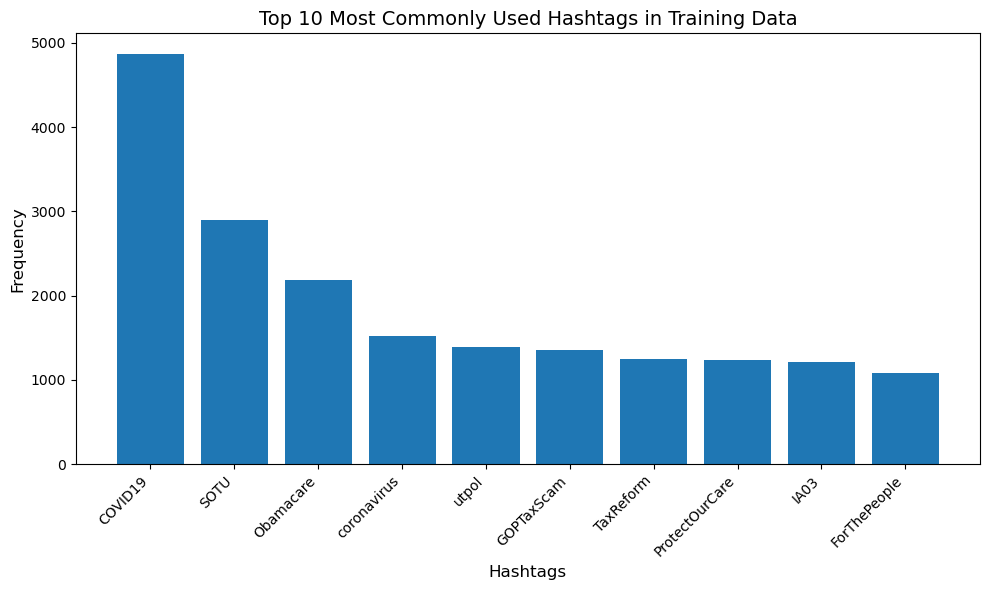

In [9]:
# Prepare data for plotting
hashtags, counts = zip(*top_hashtags)

plt.figure(figsize=(10, 6))
plt.bar(hashtags, counts)
plt.xlabel('Hashtags', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Most Commonly Used Hashtags in Training Data', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

### Findings: Due to the timing of the tweets (from 2007-2022), we notice very commonly used COVID 19 and political hashtag use. In the top 4 hashtags we see 2 referring to the Coronavirus, emphasizing its significant impact on its severity and discourse. The other two, SOTU (State of the Union) and Obamacare relate to political events and policies, which seem to bee key topics of social media discourse
### c) To answer this question, first please read the description above DW-NOMINATE scores provided at the beginning of this assignment document. Then, please divide your training dataset into four subsets by focusing on the following ideological dimensions: 
### a. Group 1: Dim 1 (0 to 1), Dim 2 (0 to 1) b. Group 2: Dim 1 (0 to 1), Dim 2 (0 to -1) c. Group 3: Dim 1 (0 to -1), Dim 2 (0 to 1) d. Group 4: Dim 1 (0 to -1), Dim 2) (0 to -1)
### Repeat the same analysis you have done in part b). Please create four separate bar charts with four different colors this time. Do you observe any patterns? Are your findings similar to or different from your findings in part b) ?. Please explain
### Divide dataset into 4 subsets by focusing on dimensions

In [10]:
group_1 = training_data[(training_data['dim1_nominate'] >= 0) & (training_data['dim1_nominate'] <= 1) &
                        (training_data['dim2_nominate'] >= 0) & (training_data['dim2_nominate'] <= 1)]

group_2 = training_data[(training_data['dim1_nominate'] >= 0) & (training_data['dim1_nominate'] <= 1) &
                        (training_data['dim2_nominate'] <= 0) & (training_data['dim2_nominate'] >= -1)]

group_3 = training_data[(training_data['dim1_nominate'] <= 0) & (training_data['dim1_nominate'] >= -1) &
                        (training_data['dim2_nominate'] >= 0) & (training_data['dim2_nominate'] <= 1)]

group_4 = training_data[(training_data['dim1_nominate'] <= 0) & (training_data['dim1_nominate'] >= -1) &
                        (training_data['dim2_nominate'] <= 0) & (training_data['dim2_nominate'] >= -1)]

### Use extract hashtags function from b) and create an analyze hashtags function

In [11]:
def analyze_hashtags(group, color, title):
    all_hashtags = extract_hashtags(group['hashtags'])
    hashtag_counts = Counter(all_hashtags)
    top_hashtags = hashtag_counts.most_common(10)

    # Prepare data for plotting
    hashtags, counts = zip(*top_hashtags)

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(hashtags, counts, color=color)
    plt.xlabel('Hashtags', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(top_hashtags, columns=["Hashtag", "Count"])


### Analyze and Create charts

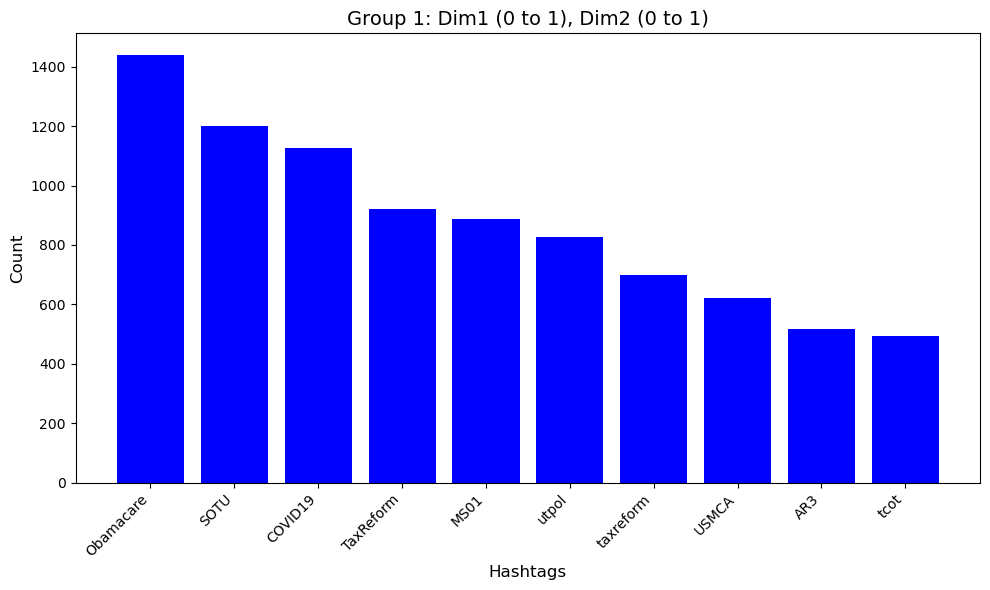

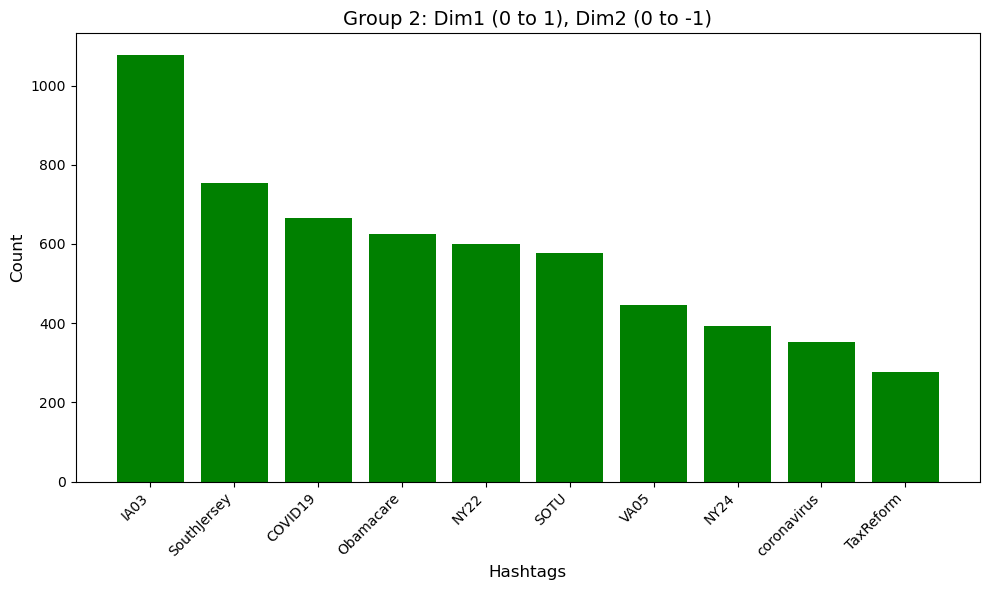

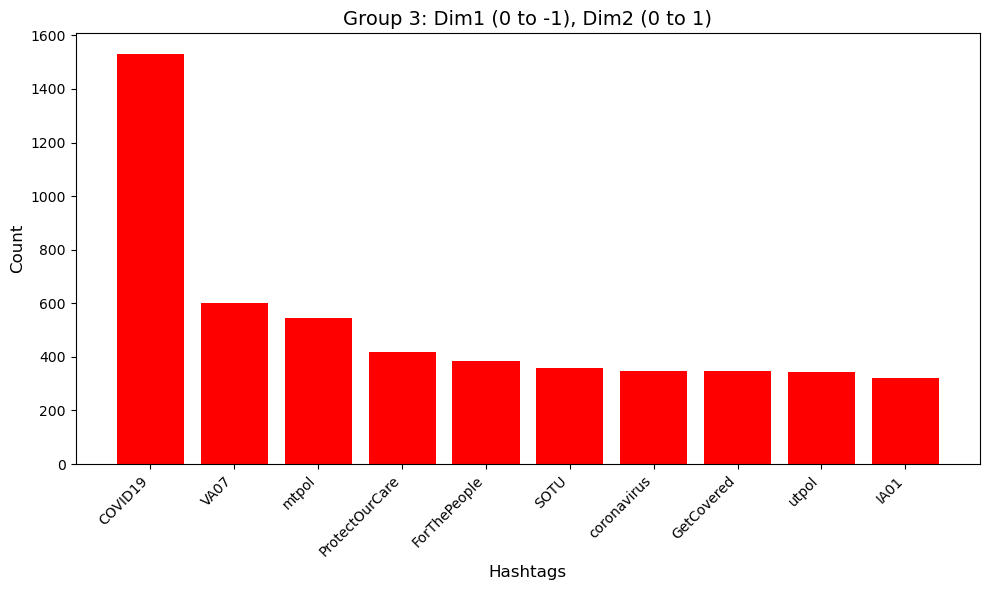

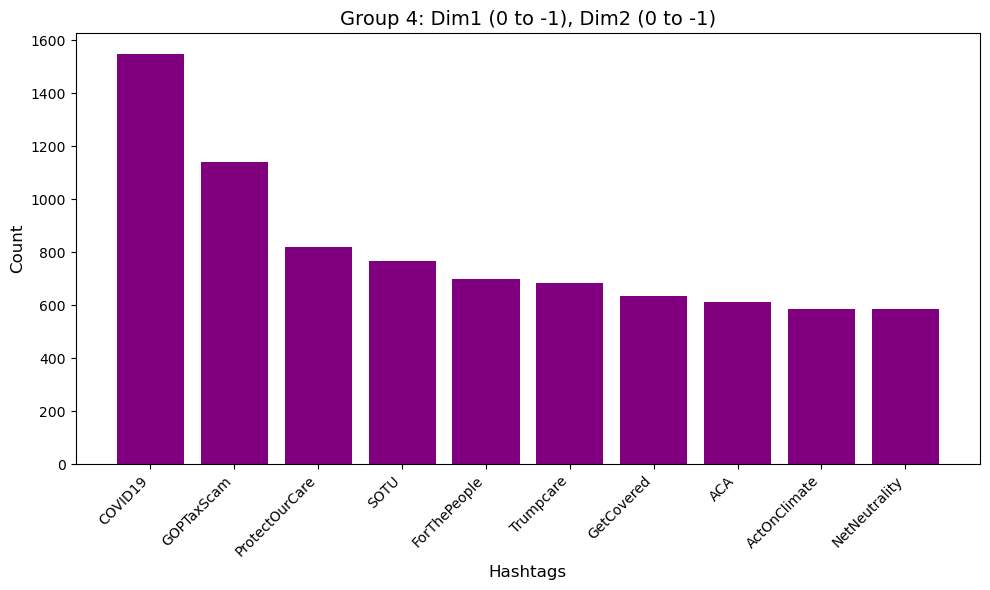

In [12]:
group_1_hashtags = analyze_hashtags(group_1, 'blue', 'Group 1: Dim1 (0 to 1), Dim2 (0 to 1)')
group_2_hashtags = analyze_hashtags(group_2, 'green', 'Group 2: Dim1 (0 to 1), Dim2 (0 to -1)')
group_3_hashtags = analyze_hashtags(group_3, 'red', 'Group 3: Dim1 (0 to -1), Dim2 (0 to 1)')
group_4_hashtags = analyze_hashtags(group_4, 'purple', 'Group 4: Dim1 (0 to -1), Dim2 (0 to -1)')

### Findings: 
### Group 1: We see greater domination from the political hashtags such as ObamaCare and SOTU, and the hashtags trending seem to be more liberal-leaning
### Group 2: We see unique hashtags dominate, such as IA03 and SouthJersey, indicating a foucs on regionality over political and COVID-related tweets
### Group 3: We see COVID 19 along with a regional VA07 tweet, but the usage of ProtectOurCare and ForThePeople indicate a more liberal focused group
### Group4: The mixture of ProtectOurCare, ActOnClimate and TrumpCare shows a mixture of political affiliatoin in this group, but it is dominated by COVID19 and GOPTaxScam

### d) Divide the training dataset into two along the 1st dimension. All observations that have a value bigger than zero (in the 1st dimension) should be designated as ‘conservative’, all other observations should be designed as ‘liberal’. Create a ridge plot that shows the changes in these values (1st dimension) through the years for two different ideological groups. Color the conservative group as red, color the liberal group as blue. (Note: This graph will structually be similar to, but empirically slightly different from the graph in the first page of the assignment [since, the training dataset does not contain any information about party membership.]) Do you observe any changes over the years? Please explain.

### Import ridge plot library and add idelogical group column based on 1st dim

In [13]:
import seaborn as sns

training_data['ideological_group'] = training_data['dim1_nominate'].apply(lambda x: 'conservative' if x > 0 else 'liberal')

### Create Ridge Plot

<Axes: xlabel='year', ylabel='dim1_nominate'>

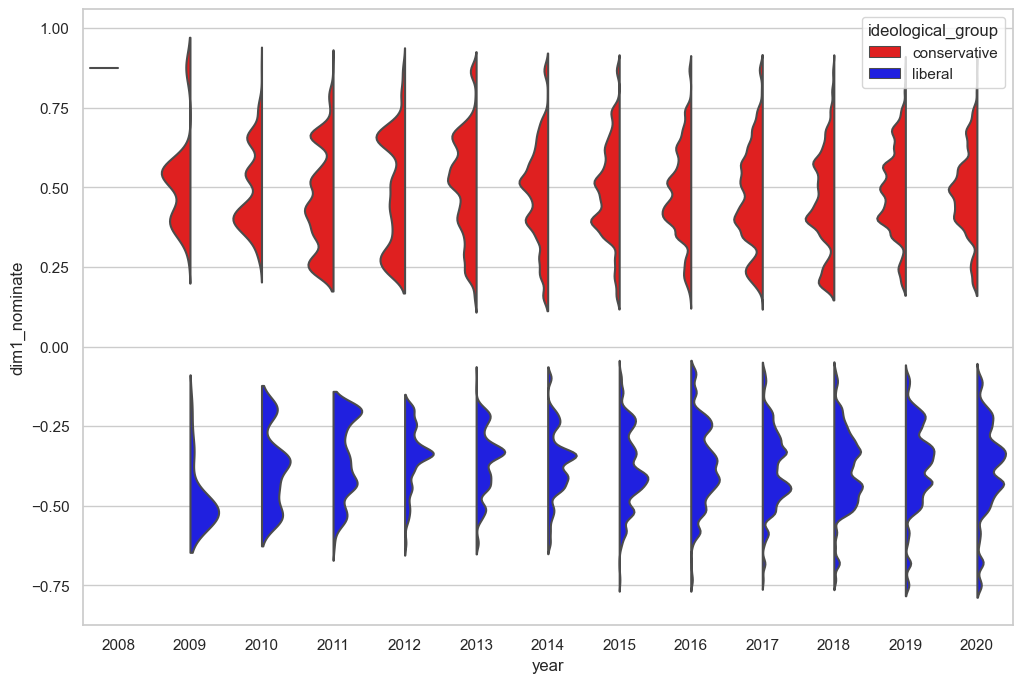

In [23]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Create the ridge plot
sns.violinplot(
    x='year',
    y='dim1_nominate',
    hue='ideological_group',
    data=training_data,
    split=True,
    palette={'conservative': 'red', 'liberal': 'blue'},
    scale='width',
    inner=None
)


### Analysis over the years: Consistent with each ideological group (conservative remains positive, liberal remains negative, with no overlaps). Conservatives are more stable in terms of density, wheras liberals shift closer to 0 over the years

### Finally, find the top-10 tweets that are ideologically most different from each other by calculating the Euclidean distances for the following:
### a. Top-10 most distant tweets along both dimensions
### b. Top-10 most distant tweets along the 1st dimension
### c. Top-10 most distant tweets along the 2nd dimension
### Please report your findings in the form of tables [tweet pairs that are ideologically distant and the distance value]. Do you observe any patterns? Please explain. Write your findings in the report. (Add the tables to the report.) (Note: If there are more than 10 tweet pairs with the same distance, you are welcome to choose the most distant tweet pairs that you find the most interesting.) 
### Import combinations library and create Euclidean Distance Function

In [24]:
from itertools import combinations

def euclidean_distance(row1, row2, dimensions):
    return np.sqrt(sum((row1[dim] - row2[dim]) ** 2 for dim in dimensions))

### Generate tweet pairs adn calculate distances for both dimensions

In [25]:
tweet_pairs = list(combinations(training_data.index[:500], 2))  # Adjust sample size if needed

# Calculate distances for both dimensions
distance_data = []
for idx1, idx2 in tweet_pairs:
    row1, row2 = training_data.loc[idx1], training_data.loc[idx2]
    dist_both = euclidean_distance(row1, row2, ['dim1_nominate', 'dim2_nominate'])
    dist_dim1 = euclidean_distance(row1, row2, ['dim1_nominate'])
    dist_dim2 = euclidean_distance(row1, row2, ['dim2_nominate'])
    
    distance_data.append((idx1, idx2, dist_both, dist_dim1, dist_dim2))

In [31]:
# Convert to DataFrame
distance_df = pd.DataFrame(distance_data, columns=["Tweet1", "Tweet2", "Distance_Both", "Distance_Dim1", "Distance_Dim2"])

distance_df

,Tweet1,Tweet2,Distance_Both,Distance_Dim1,Distance_Dim2
0,0,1,0.327884,0.317766,0.080826
1,0,2,0.477981,0.269284,0.394907
2,0,3,0.491277,0.485894,0.072523
3,0,4,0.496070,0.469684,0.159633
4,0,5,0.849319,0.621998,0.578325
...,...,...,...,...,...
124745,496,498,0.556447,0.110725,0.545319
124746,496,499,0.927033,0.631440,0.678730
124747,497,498,0.065902,0.046601,0.046598
124748,497,499,0.718479,0.695564,0.180009


### For a. Top-10 most distant tweets along both dimensions

In [32]:
top_10_both = distance_df.nlargest(10, "Distance_Both")
print("Top 10 Most Distant Tweets (Both Dimensions):")
top_10_both

Top 10 Most Distant Tweets (Both Dimensions):


,Tweet1,Tweet2,Distance_Both,Distance_Dim1,Distance_Dim2
18738,39,58,1.876241,1.612877,0.958596
18786,39,106,1.876241,1.612877,0.958596
19090,39,410,1.876241,1.612877,0.958596
22382,47,58,1.876241,1.612877,0.958596
22430,47,106,1.876241,1.612877,0.958596
22734,47,410,1.876241,1.612877,0.958596
27396,58,166,1.876241,1.612877,0.958596
27447,58,217,1.876241,1.612877,0.958596
27612,58,382,1.876241,1.612877,0.958596
27660,58,430,1.876241,1.612877,0.958596


### For b. Top-10 most distant tweets along the 1st dimension

In [33]:
top_10_dim1 = distance_df.nlargest(10, "Distance_Dim1")
print("Top 10 Most Distant Tweets (1st Dimension):")
top_10_dim1

Top 10 Most Distant Tweets (1st Dimension):


,Tweet1,Tweet2,Distance_Both,Distance_Dim1,Distance_Dim2
18738,39,58,1.876241,1.612877,0.958596
18786,39,106,1.876241,1.612877,0.958596
19090,39,410,1.876241,1.612877,0.958596
22382,47,58,1.876241,1.612877,0.958596
22430,47,106,1.876241,1.612877,0.958596
22734,47,410,1.876241,1.612877,0.958596
27396,58,166,1.876241,1.612877,0.958596
27447,58,217,1.876241,1.612877,0.958596
27612,58,382,1.876241,1.612877,0.958596
27660,58,430,1.876241,1.612877,0.958596


### For c. Top-10 most distant tweets along the 2nd dimension

In [34]:
top_10_dim2 = distance_df.nlargest(10, "Distance_Dim2")
print("Top 10 Most Distant Tweets (2nd Dimension):")
top_10_dim2

Top 10 Most Distant Tweets (2nd Dimension):


,Tweet1,Tweet2,Distance_Both,Distance_Dim1,Distance_Dim2
7993,16,146,1.712864,0.107448,1.709491
8329,16,482,1.712864,0.107448,1.709491
62382,146,260,1.712864,0.107448,1.709491
96291,260,482,1.712864,0.107448,1.709491
8060,16,213,1.653275,0.120848,1.648852
8210,16,363,1.653275,0.120848,1.648852
83755,213,260,1.653275,0.120848,1.648852
96172,260,363,1.653275,0.120848,1.648852
7940,16,93,1.780470,0.748159,1.615653
42295,93,260,1.780470,0.748159,1.615653


### Patterns: The top tweet pairs for both dimensions is the exact same as b. the tope 10 most distant tweets along the 1st dimension, therefore the first dimension contributes the most towards ideological differences. The lower distance values of the 2nd dimension indicate that the divide is generally smaller, meaning that regional divdies are less significant
# Part II: Model Creation and Prediction
### Reimport Libraries and reload training data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.preprocessing import MinMaxScaler
import time
import nltk
from nltk.corpus import stopwords
import demoji
import string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import re

In [2]:
train_data = pd.read_csv("Desktop/DSCC383W/MiniP/training_data.csv")

train_data

,favorite_count,full_text,hashtags,retweet_count,year,dim1_nominate,dim2_nominate
0,8,b'WATCH my speech on the @SenateFloor to learn...,PatientFreedomAct,3,2017,0.243962,0.170366
1,2,b'Boehner delays leadership races. Only speake...,rossformajoritywhip,3,2015,0.561728,0.089540
2,5,"b""I'll be sharing #scarynumbers about #governm...",scarynumbers governmentspending,4,2014,0.513246,-0.224541
3,34,"b""#OTD in '64, LBJ took important step towards...",OTD,14,2017,-0.241932,0.097843
4,23,b'My bipartisan bill is a step toward protecti...,VA07,7,2020,-0.225722,0.329999
...,...,...,...,...,...,...,...
333982,97,"b""I am working to make Social Security stronge...",ExpandSocialSecurity,29,2018,-0.423522,0.005929
333983,11,b'Climate change -&gt; altered CA forest ecosy...,actonclimate,11,2016,-0.436272,-0.546745
333984,82,b'The @USChamber and other business lobbying g...,climate,34,2019,-0.309244,-0.070852
333985,1,b'I look forward to answering constituent\xe2\...,TeleTownHall,1,2016,-0.516671,0.205851


### Text cleaning function required for grad students but helps with preprocessing

In [3]:
def text_cleaner(tweet):
    
    
    #Convert text to lower case
    text = tweet.lower()
    
    #removing the "b'" in the beginning of every tweet (The first 2 characters)
    text = text[2:]
    
    #Remove stop words
    sub_list = stopwords.words('english')
    b = text.split()
    x = []
    for i in b:
        if i not in sub_list:
            x.append(i)
    text = " ".join(x)
    
    #remove words of 3 letters or shorter
    b = text.split()
    x = []
    for i in b:
        if(len(i) > 3):
            x.append(i)
    text = " ".join(x)
    
    #remove any hyperlinks
    b = text.split()
    x = []
    for i in b:
        if  'http' not in i:
            x.append(i)
    text = " ".join(x)
    
    #remove words that start with \  -- Not sure if necessary
    b = text.split()
    x = []
    for i in b:
        if  '\\' not in i:
            x.append(i)
    text = " ".join(x)
    
    #Remove emojis
    dem = demoji.findall(text)
    for item in dem.keys():
        text = text.replace(item, '')
    
    #Remove punctuation
    text = text.translate(text.maketrans('', '', string.punctuation))
    
    return text
    

### Lemmatizer.py code

In [4]:
lemmatizer = WordNetLemmatizer()

##Tags the words in the tweets
def nltk_tag_to_wordnet_tag(nltk_tag):
    if nltk_tag.startswith('J'):
        return(wordnet.ADJ)
    elif nltk_tag.startswith('V'):
        return(wordnet.VERB)
    elif nltk_tag.startswith('N'):
        return(wordnet.NOUN)
    elif nltk_tag.startswith('R'):
        return(wordnet.ADV)
    else:          
        return(None)

##Lemmatizes the words in tweets and returns the cleaned and lemmatized tweet
def lemmatize_tweet(tweet):
    #tokenize the tweet and find the POS tag for each token
    tweet = text_cleaner(tweet) #tweet_cleaner() will be the function you will write
    nltk_tagged = nltk.pos_tag(nltk.word_tokenize(tweet))  
    #tuple of (token, wordnet_tag)
    wordnet_tagged = map(lambda x: (x[0], nltk_tag_to_wordnet_tag(x[1])), nltk_tagged)
    lemmatized_tweet = []
    for word, tag in wordnet_tagged:
        if tag is None:
            #if there is no available tag, append the token as is
            lemmatized_tweet.append(word)
        else:        
            #else use the tag to lemmatize the token
            lemmatized_tweet.append(lemmatizer.lemmatize(word, tag))
    return(" ".join(lemmatized_tweet))

### Lemmatize and Clean Training Data; report time

In [5]:
# Start measuring time
start_time = time.time()

train_data['text_clean'] = train_data['full_text'].apply(lemmatize_tweet)


elapsed_time = time.time() - start_time
print(f"Elapsed time for cleaning and lemmatizing: {elapsed_time} seconds")

Elapsed time for cleaning and lemmatizing: 678.1586818695068 seconds


### Load and lemmatize test data

In [6]:
test_data = pd.read_csv('Desktop/DSCC383W/MiniP/test_data.csv')

In [7]:
test_data['text_clean'] = test_data['full_text'].apply(lemmatize_tweet)

### Add cleaned data and hashtags to training/test data

In [8]:
train_data['new_text_clean'] = train_data['text_clean'] + " " + train_data['hashtags'] 

test_data['new_text_clean'] = test_data['text_clean'] + " " + test_data['hashtags']

### Define training/test variables, Run LGM model, report results

In [9]:
# Start measuring time
start_time = time.time()

#Prepare the training and test data
X_train = train_data['new_text_clean'].astype(str)
y_train = train_data[['dim1_nominate', 'dim2_nominate']]

X_test = test_data['new_text_clean'].astype(str)
test_ids = test_data['Id']  #Keep track of the IDs for submission

#Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Define the LightGBM model
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor

lgb_regressor = lgb.LGBMRegressor(boosting_type='gbdt', num_leaves=100, max_depth=-1, n_estimators=4000, learning_rate=0.07, n_jobs=-1)
regressor = MultiOutputRegressor(lgb_regressor)

#Train the model on the entire training dataset
regressor.fit(X_train_tfidf, y_train)

#Make predictions on the test dataset
y_test_pred = regressor.predict(X_test_tfidf)

#Create a data frame with the predictions and the test IDs
predictions = pd.DataFrame(y_test_pred, columns=['dim1_nominate', 'dim2_nominate'])

#Combine the predictions with the IDs
submission = pd.concat([test_ids, predictions], axis=1)

#Save the submission file
submission.to_csv('Desktop/DSCC383W/MiniP/predictions.csv', index=False)


elapsed_time = time.time() - start_time
print(f"Elapsed time for training: {elapsed_time} seconds")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.805063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 479174
[LightGBM] [Info] Number of data points in the train set: 333987, number of used features: 9908
[LightGBM] [Info] Start training from score 0.026034
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.216544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 479174
[LightGBM] [Info] Number of data points in the train set: 333987, number of used features: 9908
[LightGBM] [Info] Start training from score 0.007268
Elapsed time for training: 1259.383295059204 seconds


### Hyperparameter Tuning (For model)

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

# Define parameter grid with 18 combinations
param_grid = {
    'estimator__max_depth': [-1],
    'estimator__learning_rate': [0.07, 0.08],
    'estimator__n_estimators': [4250, 4000, 3750],
    'estimator__num_leaves': [50, 100, 150]
}

# Initialize LightGBM model
base_model = lgb.LGBMRegressor(boosting_type='gbdt', n_jobs=-1)
model = MultiOutputRegressor(base_model)

# Perform Grid Search
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

KeyboardInterrupt: 

### Report best set of parameters for tuning

In [ ]:
# Best parameters
best_params = grid_search.best_params_
best_params